## Plots de treino

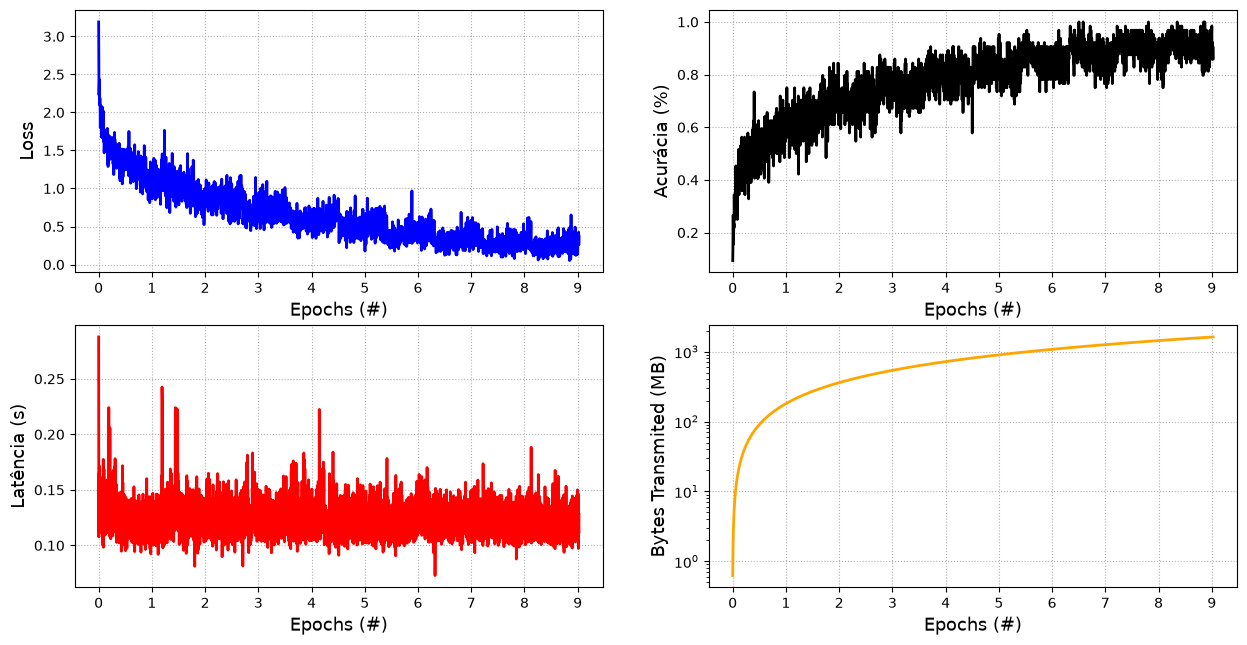

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

current_dir = Path().cwd()

client0_df = pd.read_csv(current_dir / 'results' / 'results_client_0.csv')
client1_df = pd.read_csv(current_dir / 'results' / 'results_client_1.csv')
client2_df = pd.read_csv(current_dir / 'results' / 'results_client_2.csv')


fig, ax = plt.subplots(2, 2, figsize=(15, 7.5))
ax      = ax.flatten()
sns.lineplot(x=client0_df.index, y=client0_df.loss, color='b', ax=ax[0], linewidth=2)
sns.lineplot(x=client0_df.index, y=client0_df.acc, color='k', ax=ax[1], linewidth=2)
sns.lineplot(x=client0_df.index, y=client0_df.latencia, color='r', ax=ax[2], linewidth=2)
sns.lineplot(x=client0_df.index, y=client0_df.bytes_tx.cumsum(), color='orange', ax=ax[3], linewidth=2)

for _ in range(4):
    ax[_].set_xlabel('Epochs (#)', size=13)
    ax[_].grid(True, linestyle=':')
    ax[_].set_xticks((range(0, len(client0_df), 288)), ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9'))

ax[0].set_ylabel('Loss', size=13)
ax[1].set_ylabel('Acurácia (%)', size=13)
ax[2].set_ylabel('Latência (s)', size=13)
ax[3].set_ylabel('Bytes Transmited (MB)', size=13)
ax[3].set_yscale('log') 

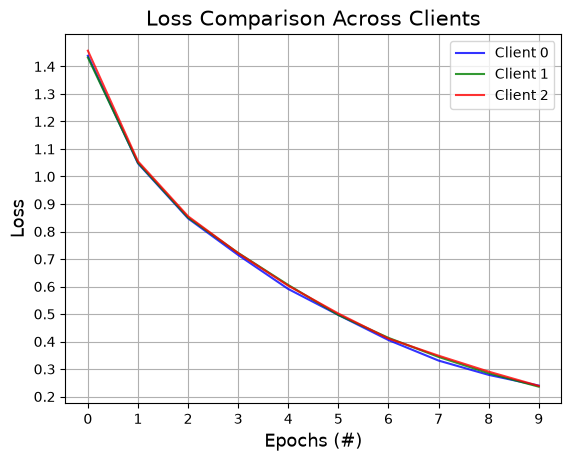

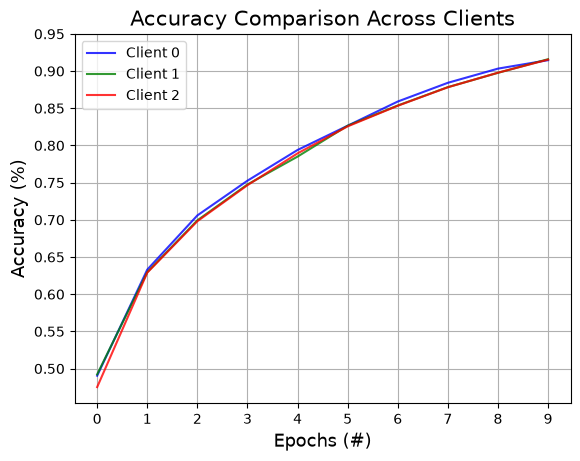

In [70]:
client0_df_agg = client0_df.groupby('epoch').agg({'loss':'mean', 'acc': 'mean'})
client1_df_agg = client1_df.groupby('epoch').agg({'loss':'mean', 'acc': 'mean'})
client2_df_agg = client2_df.groupby('epoch').agg({'loss':'mean', 'acc': 'mean'})

plt.plot(client0_df_agg.index, client0_df_agg.loss, color='b', label='Client 0', alpha=0.8)
plt.plot(client1_df_agg.index, client1_df_agg.loss, color='g', label='Client 1', alpha=0.8)
plt.plot(client2_df_agg.index, client2_df_agg.loss, color='r', label='Client 2', alpha=0.8)
plt.xlabel('Epochs (#)', size=13)
plt.ylabel('Loss', size=13)
plt.title('Loss Comparison Across Clients', size=15)
plt.legend()
plt.xticks((range(0, 10, 1)))
plt.yticks(np.arange(0.2, 1.5, 0.1))
plt.grid()
plt.show()

plt.plot(client0_df_agg.index, client0_df_agg.acc, color='b', label='Client 0', alpha=0.8)
plt.plot(client1_df_agg.index, client1_df_agg.acc, color='g', label='Client 1', alpha=0.8)
plt.plot(client2_df_agg.index, client2_df_agg.acc, color='r', label='Client 2', alpha=0.8)
plt.xlabel('Epochs (#)', size=13)
plt.ylabel('Accuracy (%)', size=13)
plt.title('Accuracy Comparison Across Clients', size=15)
plt.legend()
plt.xticks((range(0, 10, 1)))
plt.yticks(np.arange(0.5, 1, 0.05))
plt.grid()
plt.show()

## Sumário dos resultados em teste

In [56]:
test_results_df = pd.read_csv(current_dir / 'results' / 'test_results.csv')

print("Test Results Summary:")
print(test_results_df.describe())

Test Results Summary:
       client_id      loss       acc  n_batches  latencia_media  \
count        3.0  3.000000  3.000000        3.0        3.000000   
mean         1.0  1.055244  0.715345       52.0        0.011788   
std          1.0  0.006918  0.005967        0.0        0.000314   
min          0.0  1.050920  0.710637       52.0        0.011434   
25%          0.5  1.051255  0.711989       52.0        0.011665   
50%          1.0  1.051590  0.713341       52.0        0.011896   
75%          1.5  1.057406  0.717698       52.0        0.011965   
max          2.0  1.063223  0.722055       52.0        0.012034   

       latencia_total  tempo_total  bytes_tx_total  bytes_rx_total  
count        3.000000     3.000000            3.00            3.00  
mean         0.612976     2.501795           29.25            3.25  
std          0.016332     0.006793            0.00            0.00  
min          0.594582     2.494243           29.25            3.25  
25%          0.606575     2.4